In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.utils import to_categorical

In [18]:
train_data = pd.read_csv("digit.csv")
print("Shape of tarin_data:", train_data.shape)

X = train_data.iloc[:, 1:]
y = train_data.iloc[:, 0]

print("Shape of X after seperating feaures:", X.shape)

Shape of tarin_data: (42000, 785)
Shape of X after seperating feaures: (42000, 784)


In [19]:
# Check if X is not a pandas DataFrame
# If it is not, convert it into DataFrame 
# This ensures that DataFrme modules like .apply can be used sefty 
if not isinstance(X, pd.DataFrame):
    x = pd.DataFrame(x)

# Convert all values in X to nemeric type
# If any values cannot be converted, replace it with NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Repalce all NaN (missing/invalid) values with 0 
# This prevents error during the model training 
X = X.fillna(0)

# Convert DataFrame to NumPy array
# Normalize pixel values from range(0-255) to (0-1)
# Neural networks train better with normalized inputs
X = X.values / 255.0

# Reshape the flattened image data into 28x28 format
# -1 automatically determines number of samples
# 28 = image height
# 28 = image width
# 1 = number of channels (grayscale image)
X = X.reshape(-1, 28, 28, 1)

print("Shape of X after reshaping: ", X.shape)

Shape of X after reshaping:  (42000, 28, 28, 1)


In [20]:
y = to_categorical(y, num_classes=10)
print("Shape of y after one-hot encoding: ", y.shape)

Shape of y after one-hot encoding:  (42000, 10)


In [21]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_tarin shape:", X_train.shape)

X_tarin shape: (33600, 28, 28, 1)


In [24]:
model = Sequential([
    Input(shape=(28, 28, 1)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9088 - loss: 0.3107 - val_accuracy: 0.9463 - val_loss: 0.1768
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9603 - loss: 0.1330 - val_accuracy: 0.9650 - val_loss: 0.1190
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9733 - loss: 0.0887 - val_accuracy: 0.9667 - val_loss: 0.1075
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9804 - loss: 0.0642 - val_accuracy: 0.9675 - val_loss: 0.1095
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9828 - loss: 0.0527 - val_accuracy: 0.9700 - val_loss: 0.1033
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9879 - loss: 0.0379 - val_accuracy: 0.9671 - val_loss: 0.1080
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9892 - loss: 0.0326 - val_accuracy: 0.9723 - val_loss: 0.0912
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9907 - loss: 0.0273 - 

263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.1055
Valudation Accuracy: 97.46%


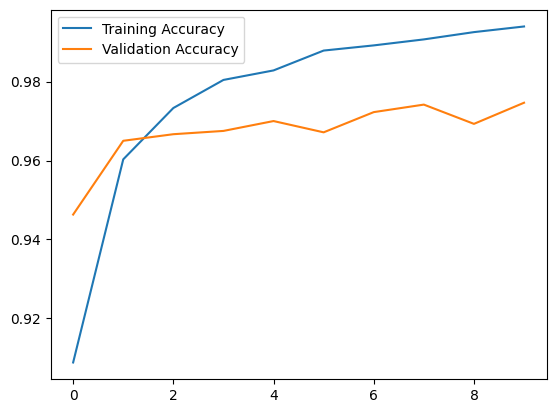

In [27]:
val_loss, val_acccuracy = model.evaluate(X_val, y_val)
print(f"Valudation Accuracy: {val_acccuracy * 100:.2f}%")
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

1313/1313 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


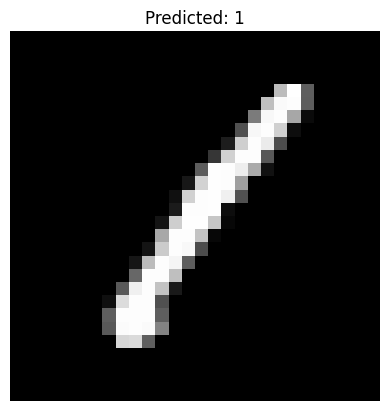

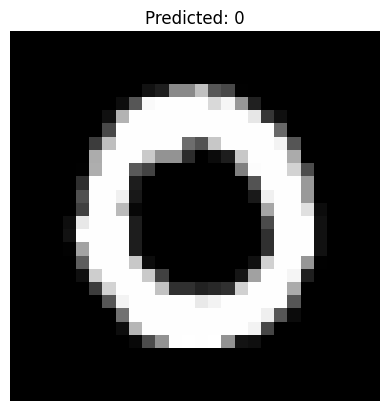

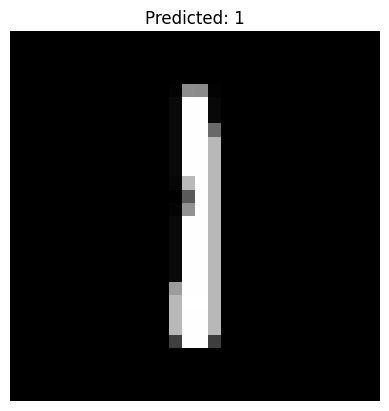

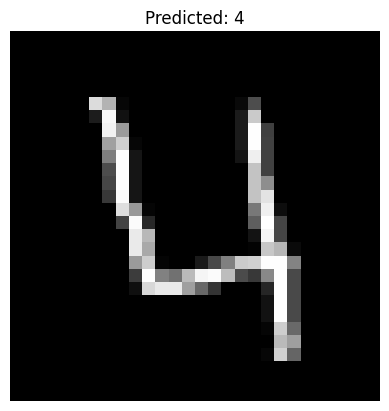

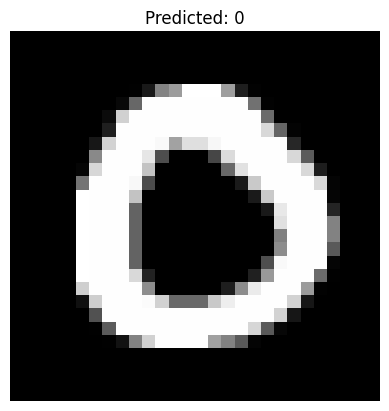

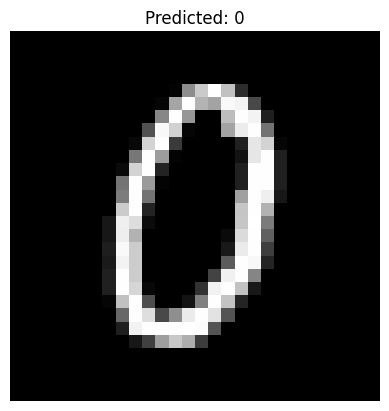

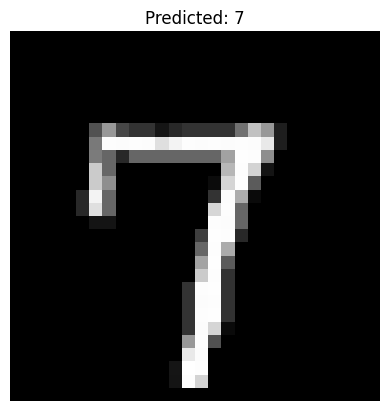

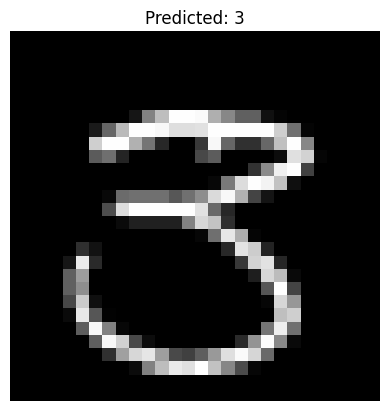

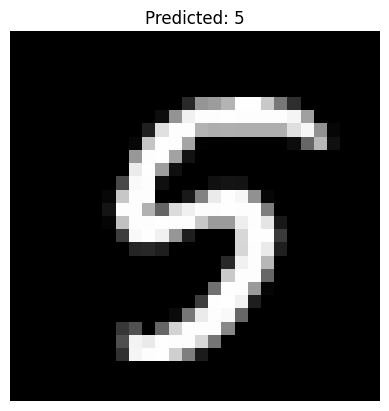

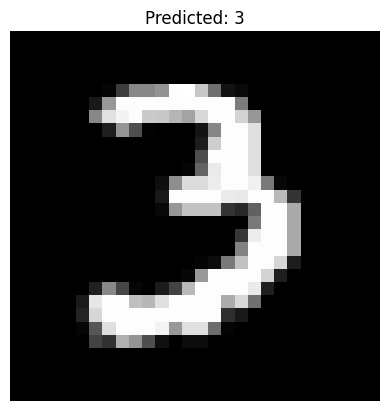

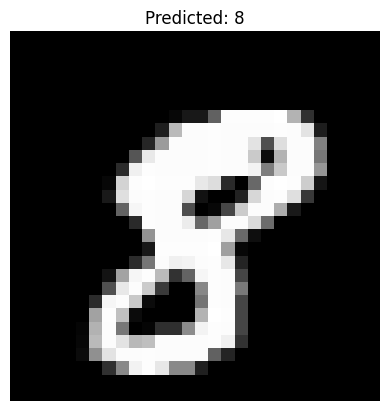

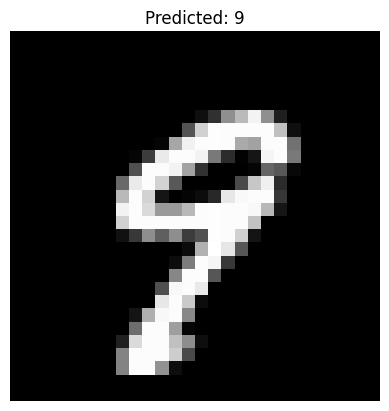

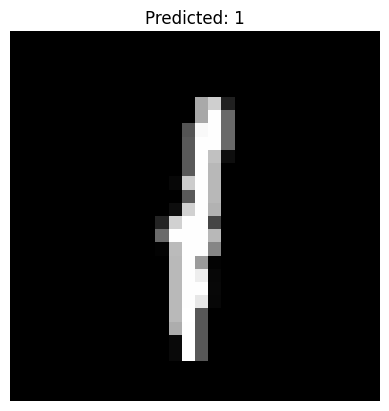

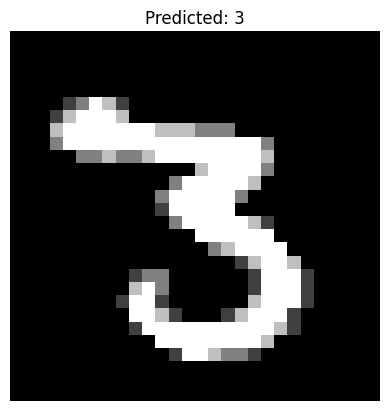

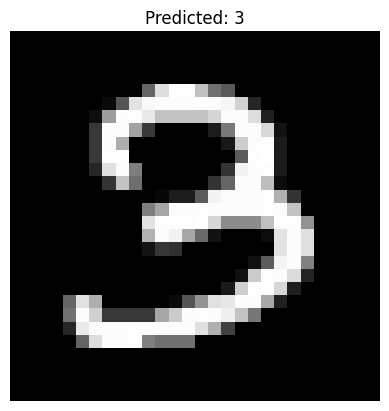

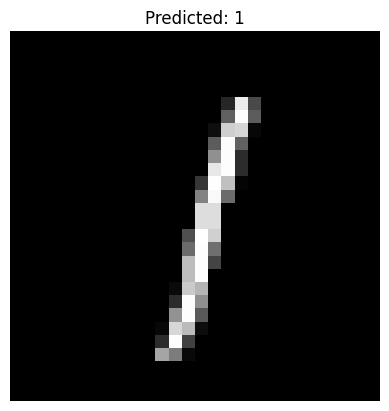

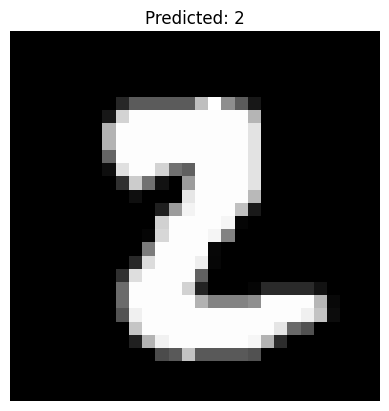

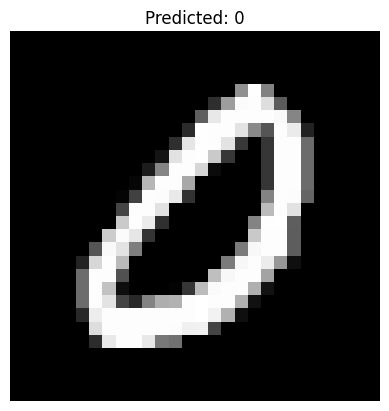

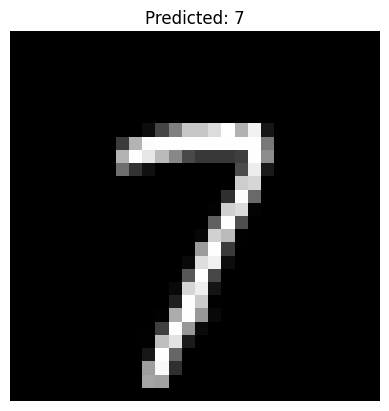

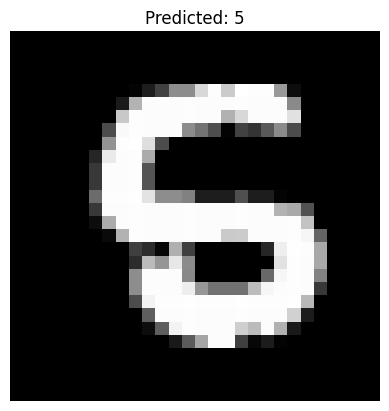

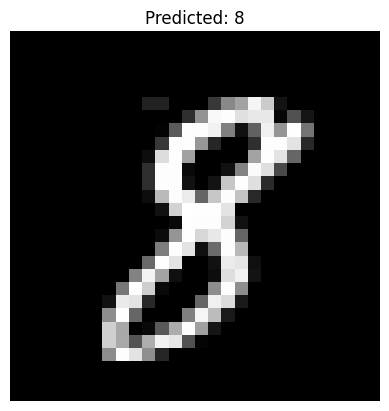

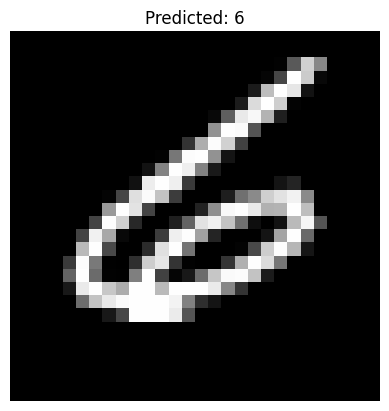

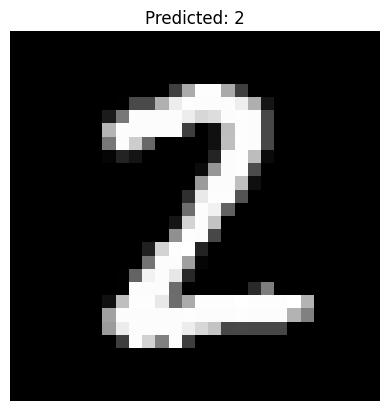

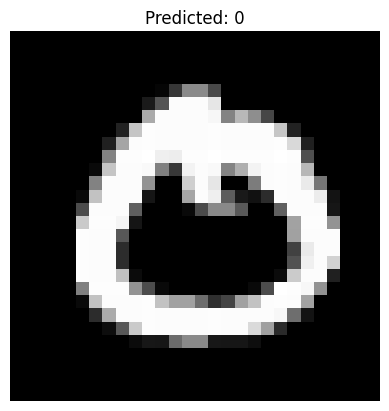

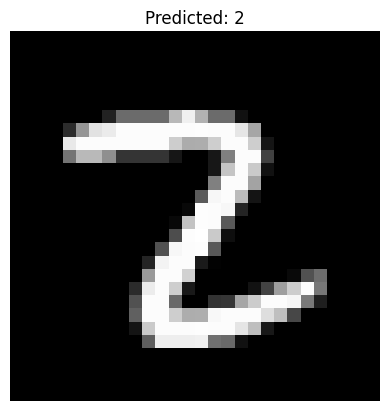

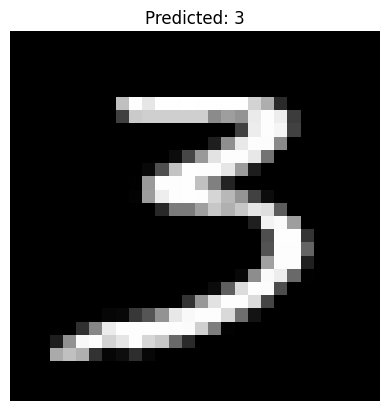

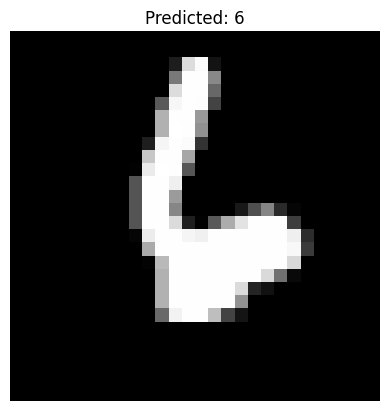

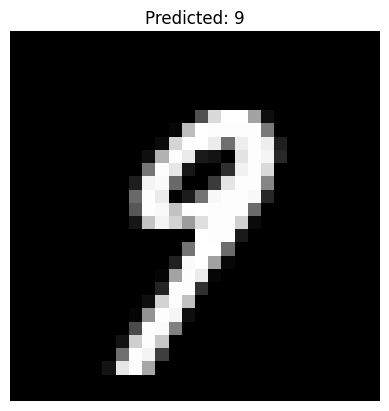

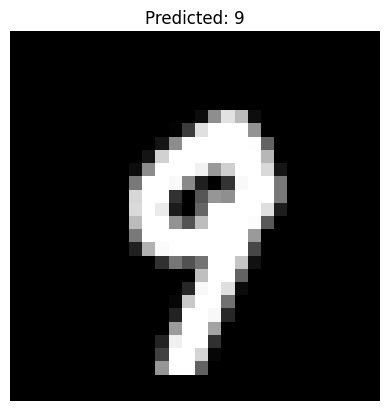

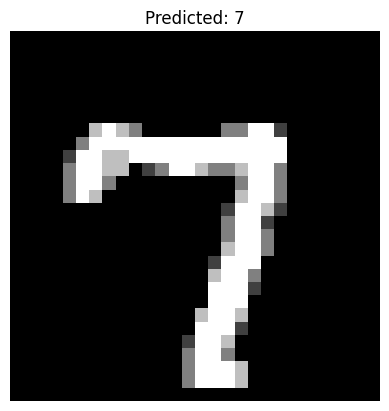

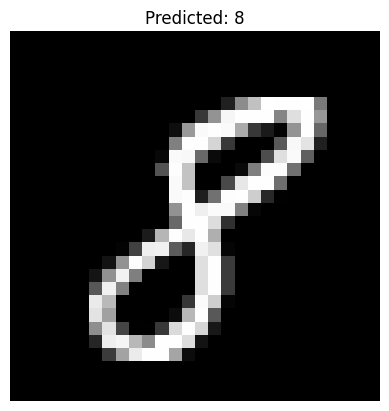

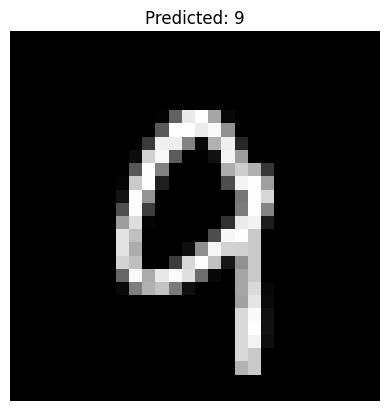

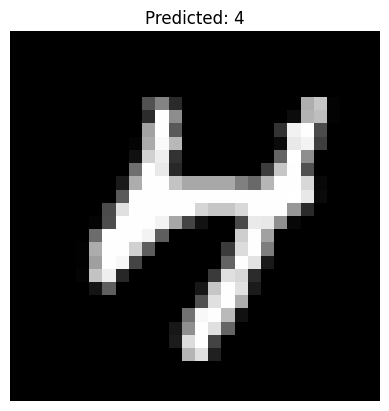

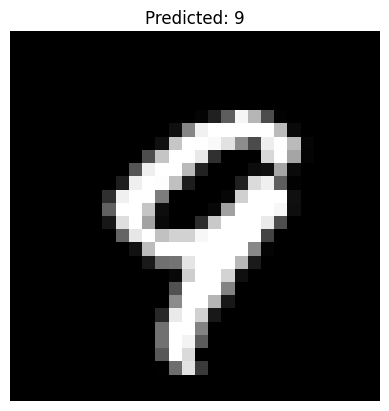

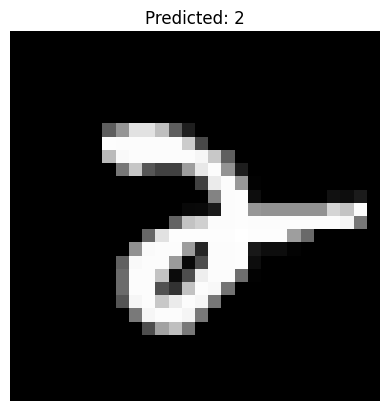

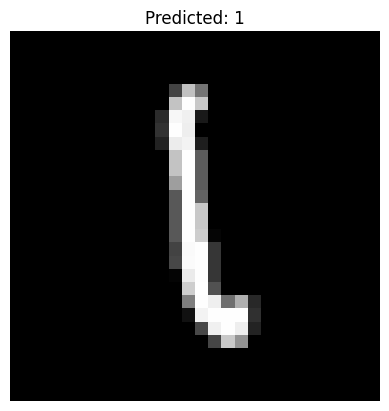

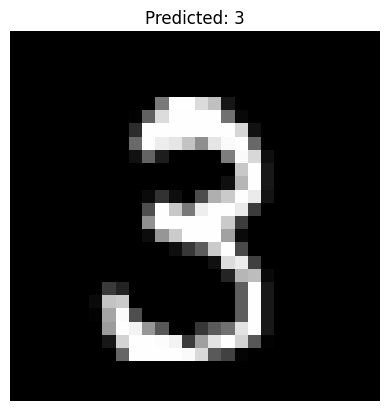

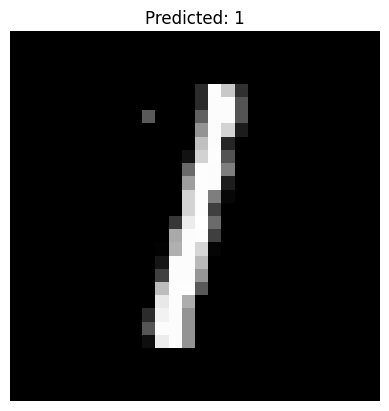

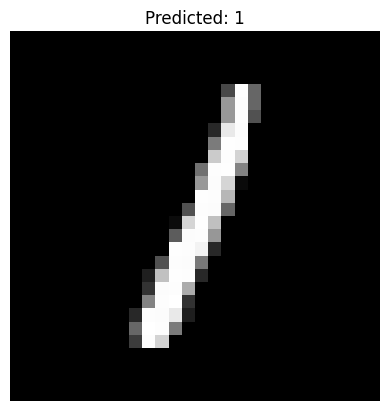

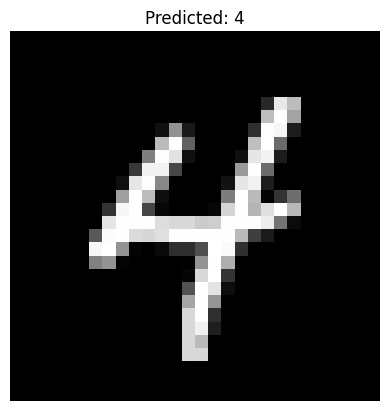

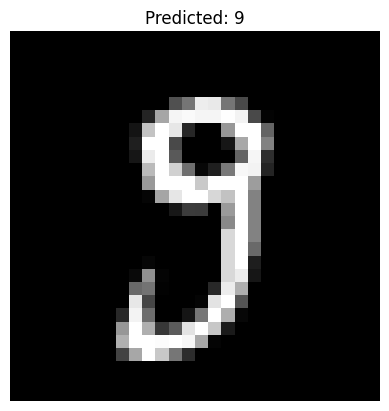

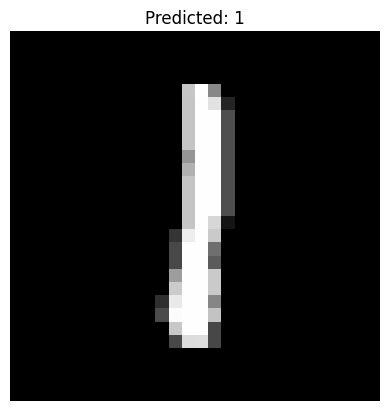

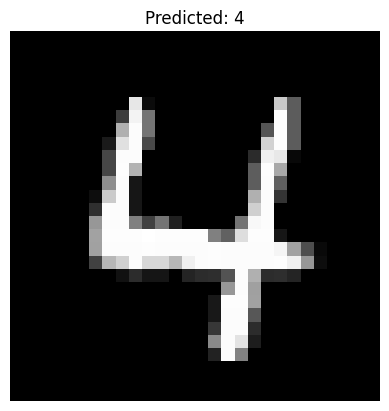

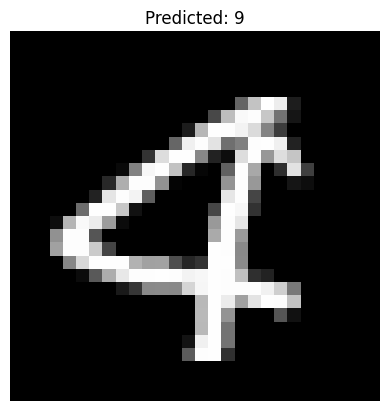

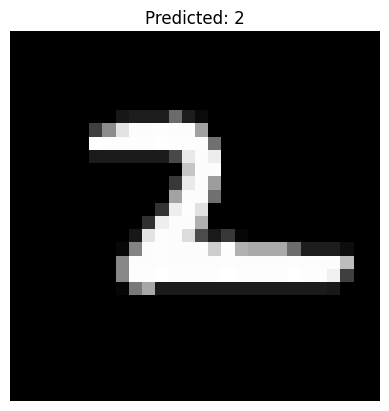

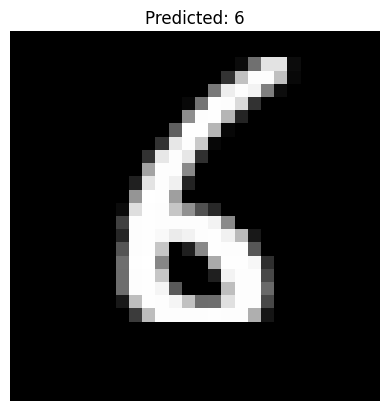

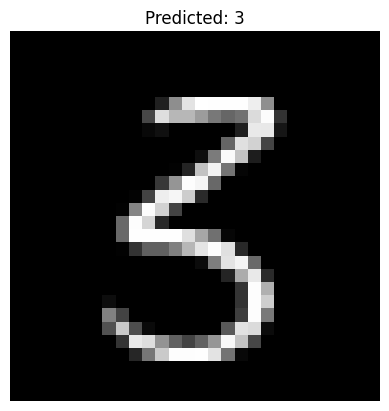

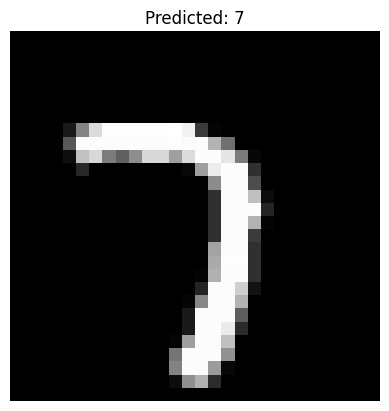

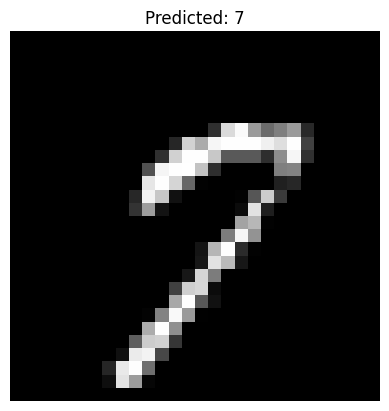

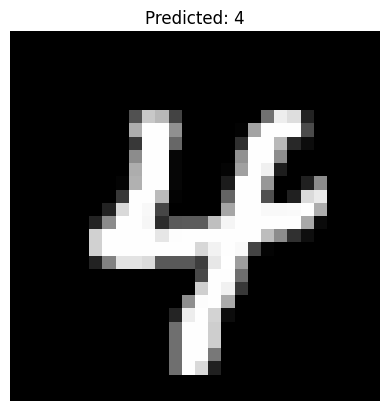

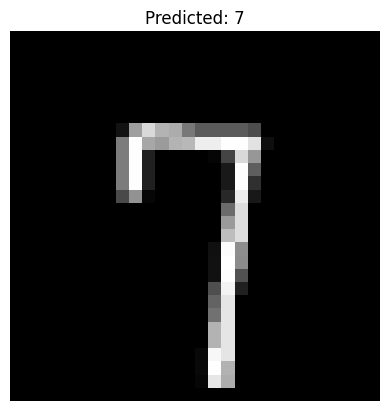

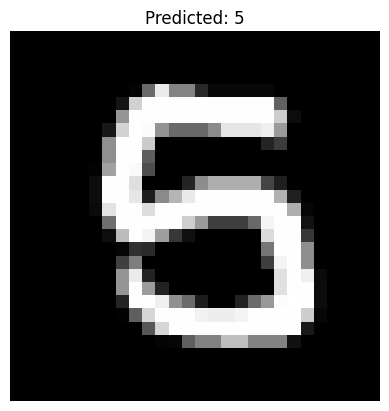

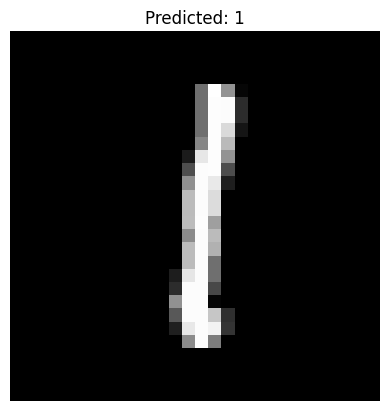

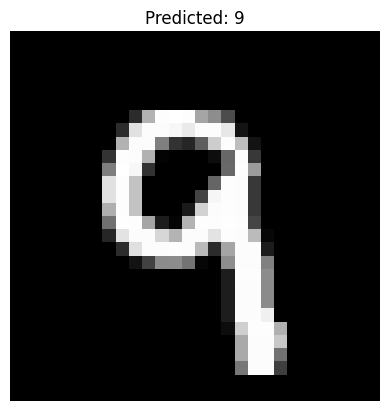

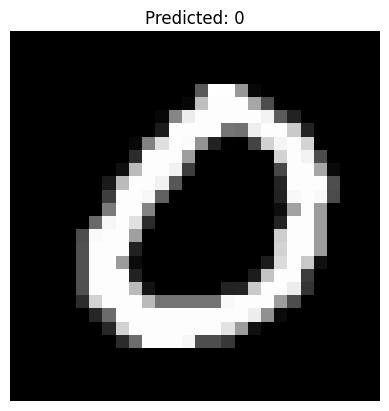

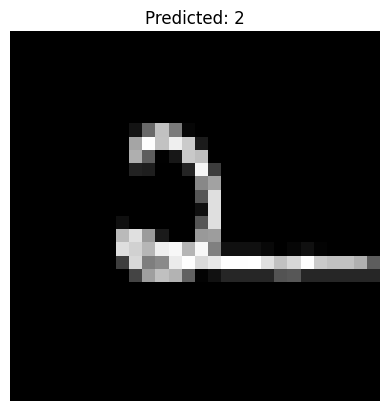

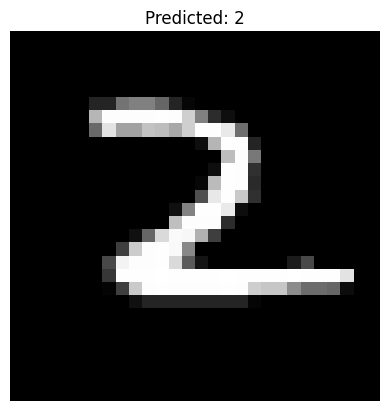

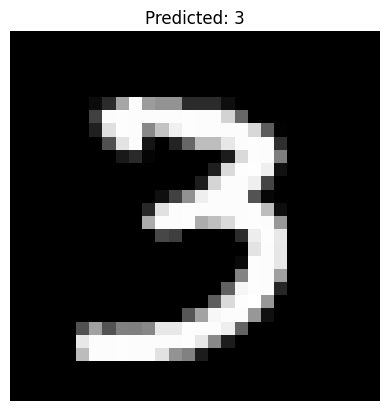

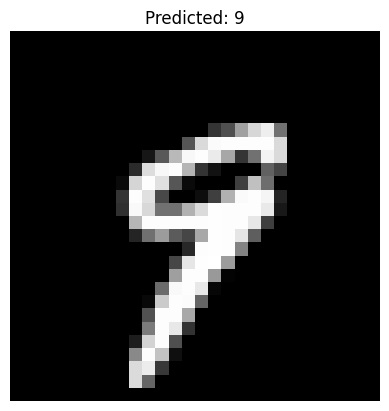

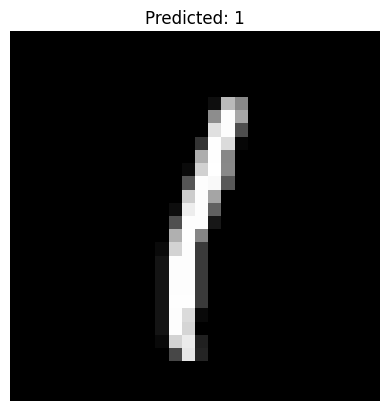

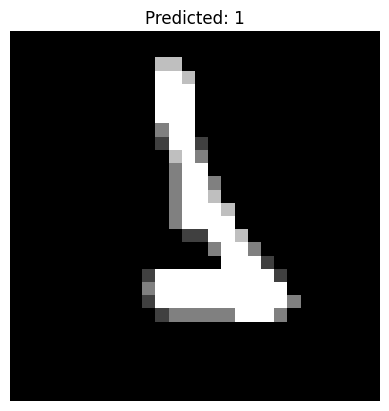

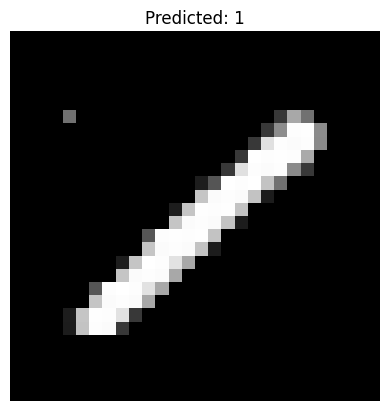

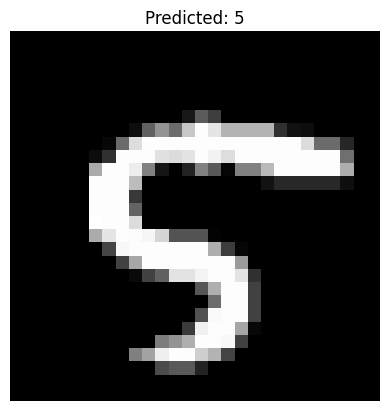

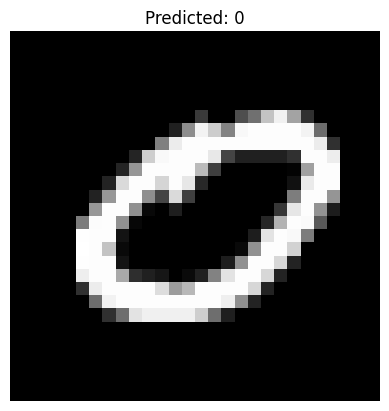

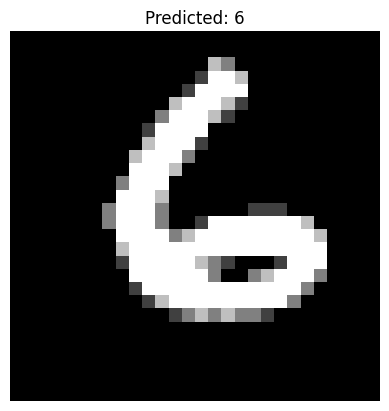

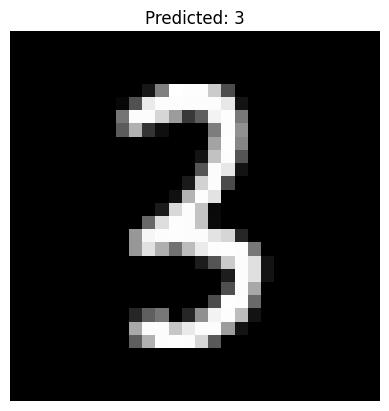

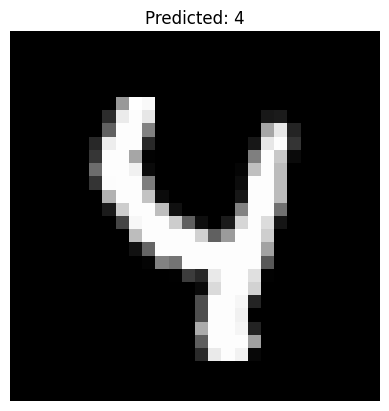

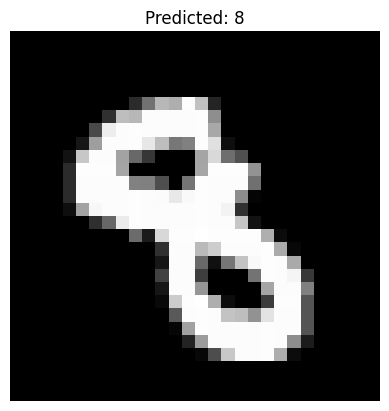

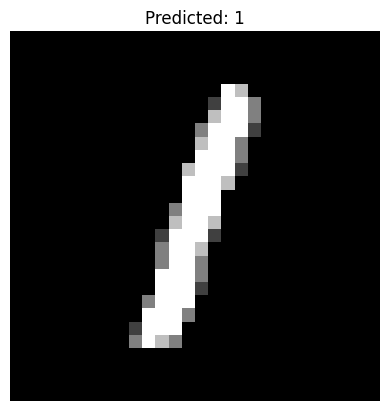

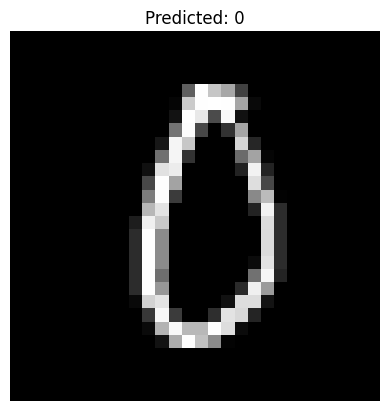

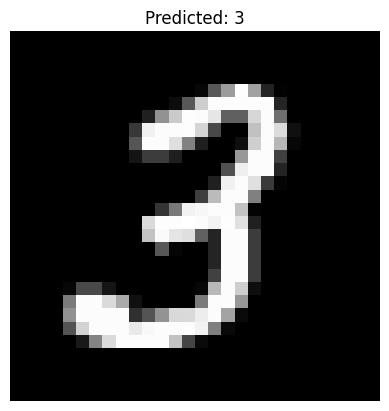

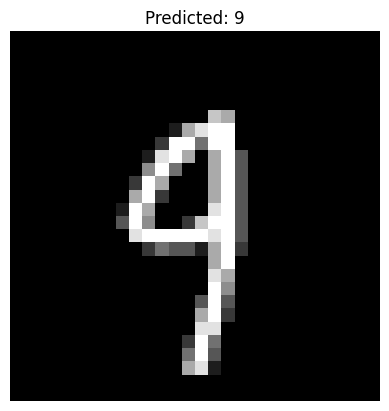

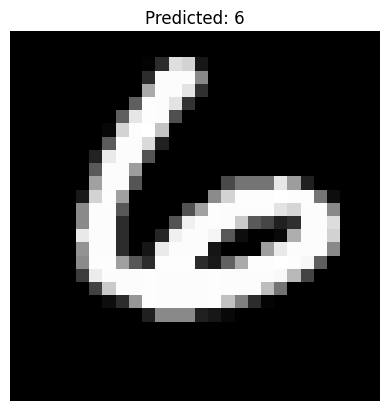

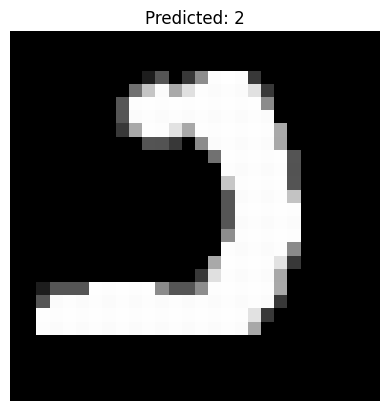

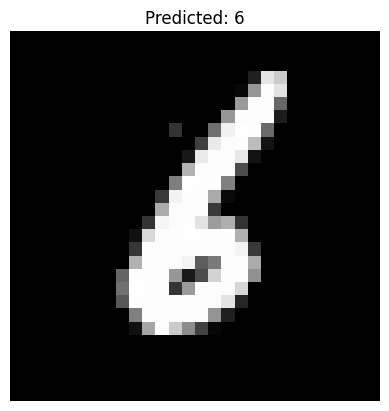

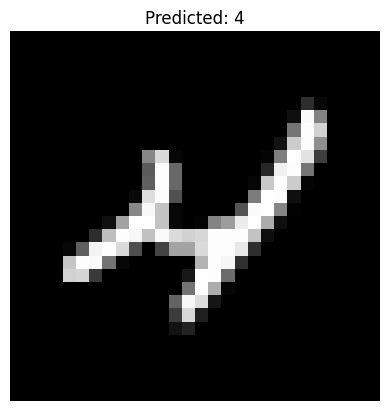

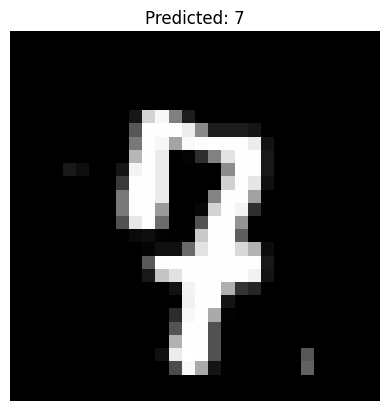

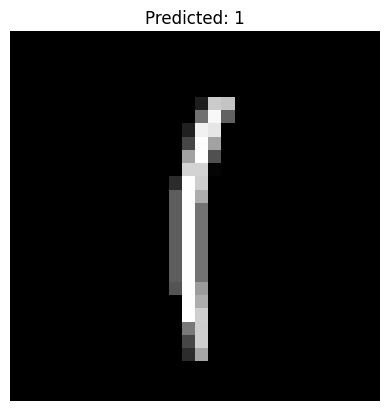

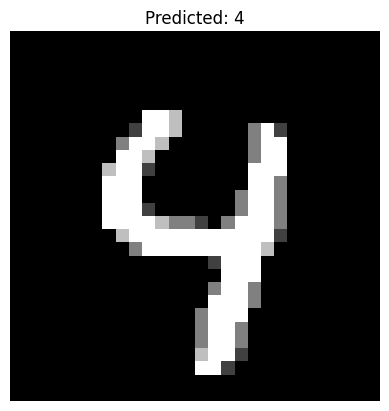

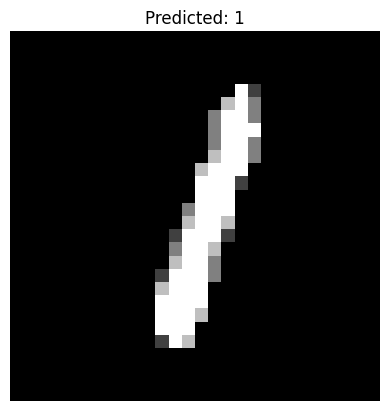

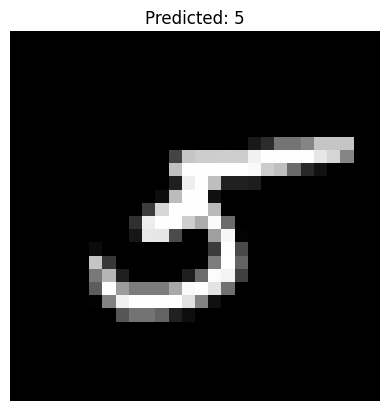

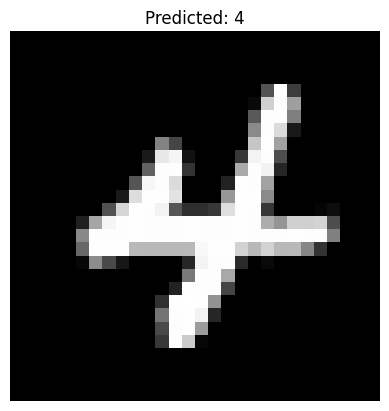

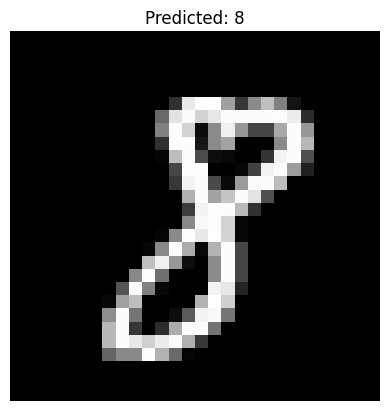

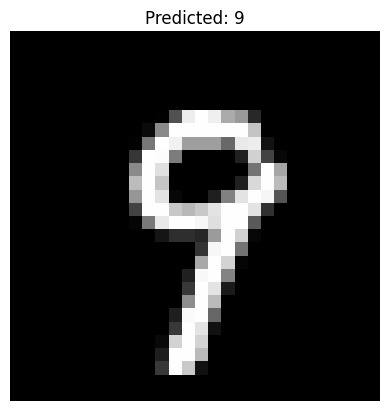

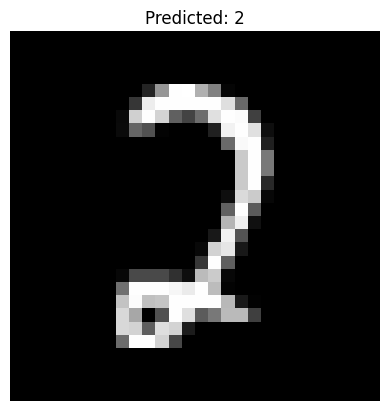

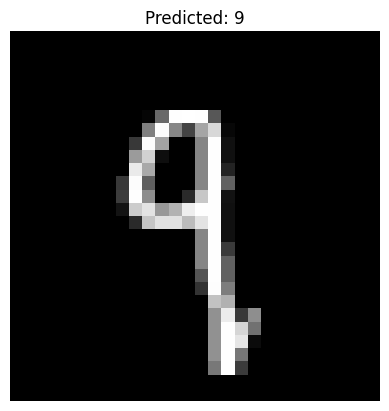

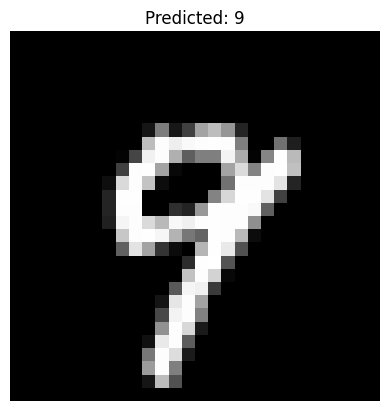

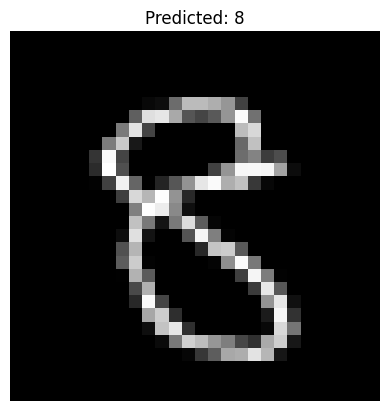

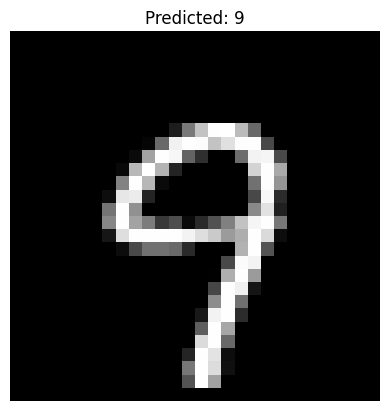

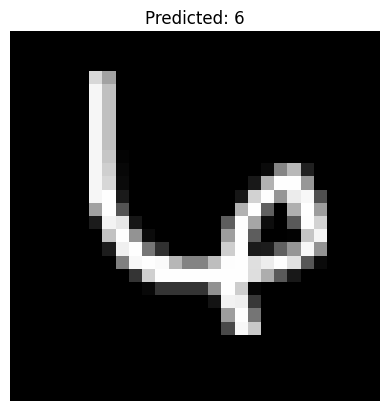

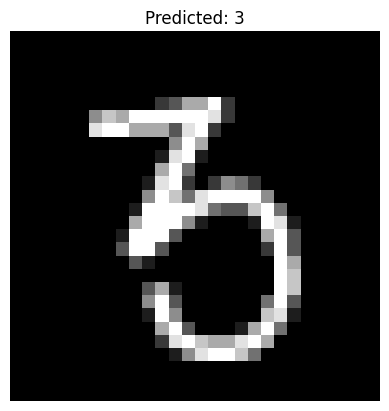

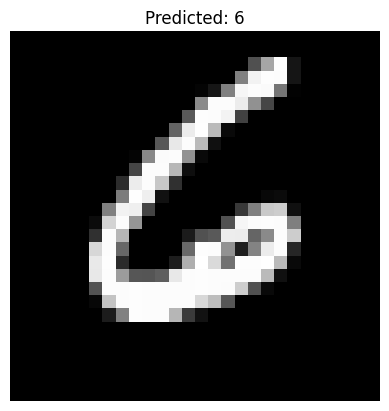

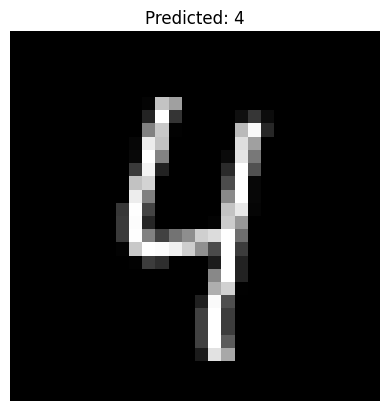

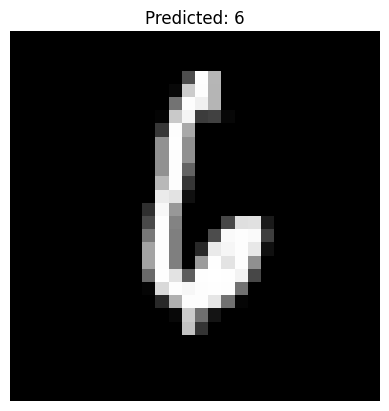

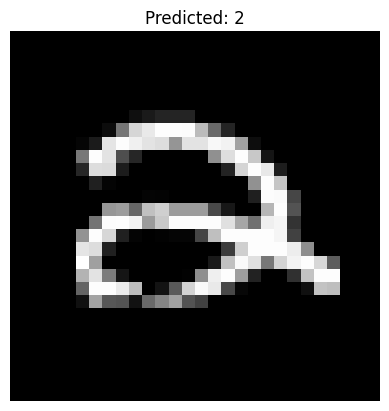

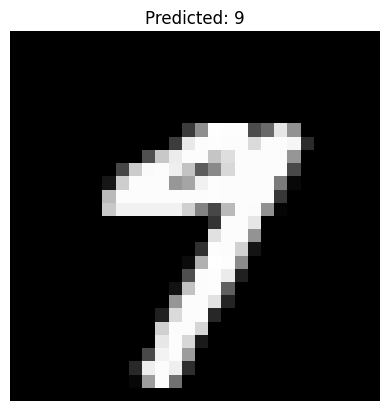

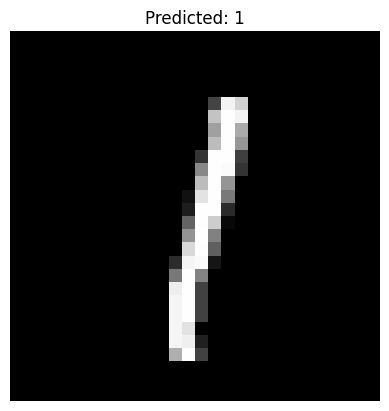

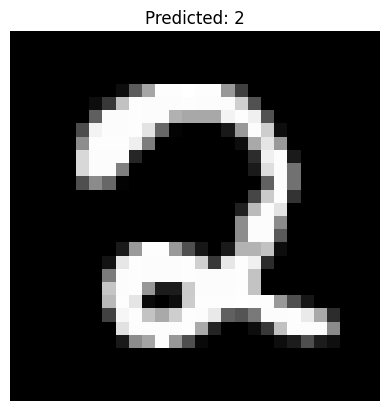

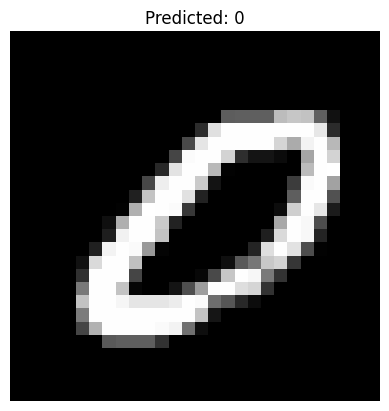

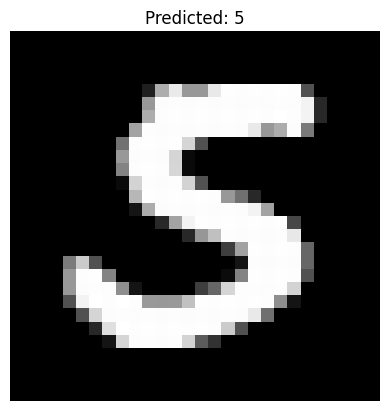

In [34]:
# Load the dataset
test_data = pd.read_csv('digit.csv')

# Remove label column (first column)
X_test = test_data.iloc[:, 1:].values / 255.0  

# Reshape to (samples, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Make predictions
predictions = model.predict(X_test)

# Get predicted digit (highest probability index)
predicted_labels = np.argmax(predictions, axis=1)

# Show first 5 predictions
for i in range(100):
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_labels[i]}")
    plt.axis('off')
    plt.show()